<a href="https://colab.research.google.com/github/JuanReyesAn/Data-Science-Portfolio-C21/blob/main/Sunny_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chat Metrics

##Impots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Data Collection

In [2]:
file_path = '/content/chat_metrics_20260730_062950 (1).xlsx'

sheets_file = pd.ExcelFile(file_path)

In [3]:

dfs = {
    sheet: pd.read_excel(file_path, sheet_name=sheet)
    for sheet in sheets_file.sheet_names
}

In [4]:
print(sheets_file.sheet_names)

['Performance', 'User Feedback', 'Daily Summary', 'Category Distribution', 'Hourly Pattern', 'Raw Data']


In [5]:
dfs = pd.read_excel(file_path, sheet_name=None)

In [6]:
dfs.keys()

dict_keys(['Performance', 'User Feedback', 'Daily Summary', 'Category Distribution', 'Hourly Pattern', 'Raw Data'])

##keys

In [7]:
performance = dfs['Performance']
user_feedback = dfs['User Feedback']
daily_summary = dfs['Daily Summary']
category_distribution = dfs['Category Distribution']
hourly_pattern = dfs['Hourly Pattern']
raw_data = dfs['Raw Data']

In [8]:
print(performance.shape)
print(user_feedback.shape)
print(daily_summary.shape)
print(category_distribution.shape)
print(hourly_pattern.shape)
print(raw_data.shape)

(18631, 10)
(786, 7)
(234, 13)
(5, 4)
(24, 2)
(18631, 23)


###Raw Data
this Data is by far the best. everything else is the by product of raw_data

In [9]:
raw_data.shape

(18631, 23)

In [10]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18631 entries, 0 to 18630
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   chat_id                  18631 non-null  object        
 1   session_id               18631 non-null  object        
 2   user_id                  18631 non-null  object        
 3   correlation_id           18631 non-null  object        
 4   timestamp                18631 non-null  datetime64[ns]
 5   date                     18631 non-null  datetime64[ns]
 6   hour                     18631 non-null  int64         
 7   day_of_week              18631 non-null  object        
 8   processing_time_seconds  18631 non-null  float64       
 9   total_tokens             18631 non-null  int64         
 10  input_tokens             18631 non-null  int64         
 11  output_tokens            18631 non-null  int64         
 12  model_calls              18631 n

In [11]:
# from the looks of it when the secondary_category is NaN that means there was not interaction with the chat bot
raw_data.head()

,chat_id,session_id,user_id,correlation_id,timestamp,date,hour,day_of_week,processing_time_seconds,total_tokens,...,primary_category,secondary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,514b2daa-fdad-4454-ad27-d28b53bdfc8f,2025-12-01 17:43:26.317,2025-12-01,17,Monday,2.707687,6935,...,greetings,NaN,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...
1,282ee6d2-7636-4f56-a008-b5aed0db3a99,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,7cdb66c1-290d-4468-abd8-7af2ce74c4d1,2025-12-01 17:44:10.986,2025-12-01,17,Monday,6.914212,12007,...,sunport_amenities,area_locations,reporter,0,0,54,102,True,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...
2,561b0d0f-a468-437f-b18d-0f8f19b22ad6,2bbf174d-184b-4a63-bfad-62483ca6d76a,A-ea63a06a-360e-435a-a73c-2b4b3eacb835,bbfd6e82-edbf-43e4-851f-b697c5975b5d,2025-12-01 17:56:49.748,2025-12-01,17,Monday,5.940034,17029,...,sunport_amenities,area_locations,reporter,0,0,53,140,True,How do i get to the airport from downtown Albu...,I am unable to provide directions to the airpo...
3,6479cd1e-d8d9-4be4-9e40-63bc844d1c2c,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,A-ea63a06a-360e-435a-a73c-2b4b3eacb835,dc705666-f916-4340-a9dc-de36dbccc3ce,2025-12-01 18:05:36.912,2025-12-01,18,Monday,3.768406,18477,...,sunport_amenities,area_locations,reporter,0,0,53,168,True,How do i get to the airport from downtown albu...,I can give you directions from downtown Albuqu...
4,5c01f807-5abd-49c9-b594-b80dc068b953,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,A-ea63a06a-360e-435a-a73c-2b4b3eacb835,5a96c9d2-afdc-4651-bdf3-ee87617e225e,2025-12-01 18:05:50.201,2025-12-01,18,Monday,4.330594,20034,...,greetings,NaN,reporter,0,0,7,191,False,driving,"Okay, the fastest driving route from downtown ..."


In [12]:
# want to know what the secondary_category does and why it is NaN for half of the data
nan_followers = raw_data[raw_data['secondary_category'].isna()]



nan_followers.tail()

,chat_id,session_id,user_id,correlation_id,timestamp,date,hour,day_of_week,processing_time_seconds,total_tokens,...,primary_category,secondary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer
18626,c16caaab-f8a8-4e99-aa8f-4e7bd5862d40,75217206-b552-4f54-a339-fac31cbee03e,A-f522979e-97fc-46ee-9e68-1f2bb0016a5d,a14decf6-2960-4968-8686-cb72f33d35da,2026-07-30 00:34:07.839,2026-07-30,0,Thursday,1.220306,9102,...,greetings,NaN,reporter,0,0,10,32,False,Live agent,Hello! How can I help you today?
18627,c9177130-297f-4b63-93ba-166dcb403431,75217206-b552-4f54-a339-fac31cbee03e,A-f522979e-97fc-46ee-9e68-1f2bb0016a5d,7f323b75-501b-4727-84e9-71e72c257b6b,2026-07-30 00:34:17.751,2026-07-30,0,Thursday,1.424250,9823,...,greetings,NaN,reporter,0,0,10,32,False,Live agent,Hello! How can I help you today?
18628,5fa25132-7314-4cc5-a96f-d80b382930ac,a6422cb8-a4bf-409f-a489-900cc9dd7694,A-d1cfae87-34f6-42c2-ae93-5f9feb8bc7b7,602f659b-10b5-43cc-a02b-3a27082bee07,2026-07-30 03:48:38.382,2026-07-30,3,Thursday,2.066835,1444,...,sunport_amenities,NaN,reporter,1,0,53,163,False,Where do I go to pick someone up who's arrivin...,"The **baggage claim** area, where arrivals are..."
18629,4ae61596-5b9c-41a0-950b-f1c0df814bbe,71a57ce1-2bf5-4120-92b0-95dbd6509af7,A-c2622cf1-a21f-4ed6-bed6-30b4705719b3,fcdbc299-ac72-44f9-be3f-bd4d41406fb0,2026-07-30 04:10:49.079,2026-07-30,4,Thursday,2.510200,11989,...,airline_logistics,NaN,reporter,0,0,168,218,False,My baggage is arriving tonight but I won’t get...,I cannot provide information on whether your b...
18630,657242ed-287f-44eb-a560-8e33a0e01ce1,71a57ce1-2bf5-4120-92b0-95dbd6509af7,A-c2622cf1-a21f-4ed6-bed6-30b4705719b3,65c3ca24-7649-4025-ac8b-81f97e4e007f,2026-07-30 04:11:12.907,2026-07-30,4,Thursday,1.943645,10124,...,greetings,NaN,reporter,0,0,17,205,False,Who can I contact,I cannot provide information on who to contact...


In [13]:
raw_data.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
timestamp,18631,2026-02-12 20:36:19.075953152,2025-12-01 17:43:26.317000,2025-12-29 01:59:53.632999936,2025-12-29 03:21:35.638000128,2026-03-24 00:14:11.188499968,2026-07-30 04:11:12.907000,NaN
date,18631,2026-02-12 11:43:39.183081984,2025-12-01 00:00:00,2025-12-29 00:00:00,2025-12-29 00:00:00,2026-03-24 00:00:00,2026-07-30 00:00:00,NaN
hour,18631.0,8.440932,0.0,2.0,3.0,17.0,23.0,8.256472
processing_time_seconds,18631.0,14.577398,0.0,2.936825,4.780313,11.605106,263.594091,27.740849
total_tokens,18631.0,252060.028823,457.0,1793.0,2569.0,10052.0,3591772.0,728484.855747
input_tokens,18631.0,244658.868016,441.0,1640.0,2360.0,9909.5,3487756.0,706896.205058
output_tokens,18631.0,7401.160807,11.0,87.0,120.0,235.0,113868.0,21658.240257
model_calls,18631.0,4.143524,0.0,3.0,4.0,5.0,36.0,2.724457
tool_calls_count,18631.0,0.687027,0.0,0.0,1.0,1.0,16.0,0.532873
step_summaries_count,18631.0,0.008319,0.0,0.0,0.0,0.0,6.0,0.147207


####Rows

In [14]:
#Rows w/Nulls
raw_data.isnull().sum().sort_values()

,0
chat_id,0
session_id,0
user_id,0
correlation_id,0
timestamp,0
date,0
hour,0
day_of_week,0
processing_time_seconds,0
total_tokens,0


In [15]:
# seems to be chat bot errors not knowing how to categorize a question?
#raw_data[raw_data['primary_category'].isna()]

In [16]:
# these are the different kinds of outputs 'primary_category gives out
raw_data['primary_category'].unique()

array(['greetings', 'sunport_amenities', 'navigation',
       'airline_logistics', 'general_info', nan], dtype=object)

In [17]:
# these are the different kinds of outputs 'secondary_category' gives out
raw_data['secondary_category'].unique()

array([nan, 'area_locations', 'routing', 'location', 'shops', 'baggage',
       'pets', 'booking_changes', 'parking', 'transportation',
       'transport_parking', 'tsa_security', 'weather', 'tourism',
       'flight_status', 'airline_info', 'accessibility',
       'unaccompanied_minors'], dtype=object)

In [18]:
raw_data.loc[
  raw_data['question'] == 'Wifi',
  ['question', 'answer', 'primary_category', 'secondary_category']
]

,question,answer,primary_category,secondary_category
814,Wifi,I am unable to directly provide the wifi infor...,NaN,NaN
15165,Wifi,"Yes, the Albuquerque International Sunport (AB...",sunport_amenities,NaN
16593,Wifi,You can access **free Wi-Fi** throughout the t...,sunport_amenities,NaN
17810,Wifi,You can connect to **free Wi-Fi** throughout t...,sunport_amenities,NaN
18378,Wifi,You can connect to **free Wi-Fi** throughout t...,sunport_amenities,NaN


In [19]:
raw_data.loc[
  raw_data['question'].str.contains('pick up', case=False, na=False),
  ['question', 'answer', 'primary_category', 'secondary_category']
]

,question,answer,primary_category,secondary_category
257,Where do I pick up bags?,I need to know your current location in the ai...,navigation,transport_parking
265,Which level is the pick up for Ubers?,The Uber pickup location at Albuquerque Intern...,sunport_amenities,transportation
290,which level has the pick up lanes for uber?,The Uber pick-up location is on the 1st level ...,sunport_amenities,transportation
468,Where do I go to pick up my bags after I land?,I need to know which airline you are flying wi...,airline_logistics,flight_status
598,Where is the pick up lane for ubers?,The Uber pick-up location is in the commercial...,sunport_amenities,transportation
...,...,...,...,...
18536,Ok so I can pick up my car after hours?,The **Rental Car Shuttle** at the **Albuquerqu...,sunport_amenities,NaN
18547,Southwest pick up number,Please provide a flight number to look up the ...,airline_logistics,NaN
18555,I am arriving on Delta flight 4098 landing in ...,"\n\n<div class=""table-wrapper""><table><thead><...",airline_logistics,NaN
18563,Curbside passenger pick up,For curbside passenger pick-up at the Albuquer...,sunport_amenities,NaN


In [20]:
raw_data.loc[
  raw_data['answer'].str.contains('status of your flight', case=False, na=False),
  ['question', 'answer', 'primary_category', 'secondary_category']
]

,question,answer,primary_category,secondary_category
818,Waiting for flight from Dallas,To check the status of your flight from Dallas...,NaN,NaN
1063,How do I check my flight status?,"To check the current status of your flight, pl...",airline_logistics,flight_status
2545,Is my flight on time?,I need the airline and flight number to check ...,sunport_amenities,area_locations
14605,The flight says arriving with no time,I can help you with that! To check the arrival...,airline_logistics,NaN
15110,When should i get to the airport for a flight?,To determine when you should get to the Albuqu...,airline_logistics,NaN
17205,Is the flight from SLC here yet? It should hav...,I need the flight number to check the status o...,airline_logistics,NaN


In [21]:
raw_data.loc[
  raw_data['session_id'].str.contains('fced9282-3523-461a-8a53-391fa279ce76', case=False, na=False),
  ['timestamp', 'session_id', 'question', 'answer', 'primary_category', 'secondary_category']
]

,timestamp,session_id,question,answer,primary_category,secondary_category
18326,2026-07-20 19:17:13.669,fced9282-3523-461a-8a53-391fa279ce76,Is the sunport wifi good enough for me to writ...,"You can connect by selecting the ""ABQ Free WiF...",sunport_amenities,NaN
18327,2026-07-20 19:17:42.098,fced9282-3523-461a-8a53-391fa279ce76,Great! Can you assist me with the script?,"```python\nprint(""Hello, World!"")\n```",greetings,NaN


In [22]:
raw_data['primary_category'].isna().sum()

np.int64(4)

In [23]:
raw_data.groupby('primary_category')['secondary_category'].unique().tolist()

[array(['baggage', 'pets', 'booking_changes', 'flight_status',
        'airline_info', 'accessibility', 'unaccompanied_minors', nan],
       dtype=object),
 array(['weather', 'tourism', nan], dtype=object),
 array([nan], dtype=object),
 array(['routing', 'location', 'transport_parking', nan], dtype=object),
 array(['area_locations', 'shops', 'parking', 'transportation',
        'tsa_security', 'flight_status', nan, 'airline_info', 'location'],
       dtype=object)]

In [24]:
#Missing Rows
# raw_data[raw_data.isnull().any(axis=1)]

In [25]:
#Duplicate rows
raw_data.duplicated().sum()

np.int64(0)

In [26]:
duplicate_sessions = raw_data[raw_data.duplicated(subset=['session_id'], keep=False)][['session_id', 'question', 'answer', 'secondary_category','primary_category']]
duplicate_sessions

,session_id,question,answer,secondary_category,primary_category
0,98f9718a-1869-4717-ba7b-44ca52972fc3,Hello,Hello! How can I help you today at the Albuque...,NaN,greetings
1,98f9718a-1869-4717-ba7b-44ca52972fc3,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...,area_locations,sunport_amenities
3,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,How do i get to the airport from downtown albu...,I can give you directions from downtown Albuqu...,area_locations,sunport_amenities
4,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,driving,"Okay, the fastest driving route from downtown ...",NaN,greetings
5,2852615e-e9e2-4789-8bae-409f3dc8d9c5,list all flights this afternoon,"Here are the flights arriving this afternoon, ...",NaN,greetings
...,...,...,...,...,...
18625,6d94c02a-eb31-48e2-af65-71843a485ce8,Wheelchair hours,"To arrange wheelchair services, please call yo...",NaN,sunport_amenities
18626,75217206-b552-4f54-a339-fac31cbee03e,Live agent,Hello! How can I help you today?,NaN,greetings
18627,75217206-b552-4f54-a339-fac31cbee03e,Live agent,Hello! How can I help you today?,NaN,greetings
18629,71a57ce1-2bf5-4120-92b0-95dbd6509af7,My baggage is arriving tonight but I won’t get...,I cannot provide information on whether your b...,NaN,airline_logistics


In [27]:
# Count how many times each session_id appears
session_counts = raw_data['session_id'].value_counts()

# Show only the ones that appear 2 or more times
duplicates_only = session_counts[session_counts >= 2]

print(duplicates_only)

session_id
63adeb7b-825b-48e6-8134-94230b1040fc    27
02075f3e-ef88-493c-b94b-93d47fedc06f    26
a7837089-0e61-4176-b501-b20ba43df553    26
2421b36b-dd98-4cbd-8c19-27f74aa6e3c0    26
3a48b4e1-117f-412f-b8a0-6d4f397f9af0    25
                                        ..
fc11b991-3ad8-4b4c-a45c-db339cac8a5e     2
c322928f-70e7-49c9-8a45-2b69c5e70a54     2
e300b06a-caff-49e8-ba98-04fa2d9ff861     2
7d4abb65-d65d-421c-9239-6873e576a528     2
bcf1279d-7d8c-4c5d-bb3c-a8b410ed38ab     2
Name: count, Length: 3239, dtype: int64


In [28]:
raw_data.head(2)

,chat_id,session_id,user_id,correlation_id,timestamp,date,hour,day_of_week,processing_time_seconds,total_tokens,...,primary_category,secondary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,514b2daa-fdad-4454-ad27-d28b53bdfc8f,2025-12-01 17:43:26.317,2025-12-01,17,Monday,2.707687,6935,...,greetings,NaN,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...
1,282ee6d2-7636-4f56-a008-b5aed0db3a99,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,7cdb66c1-290d-4468-abd8-7af2ce74c4d1,2025-12-01 17:44:10.986,2025-12-01,17,Monday,6.914212,12007,...,sunport_amenities,area_locations,reporter,0,0,54,102,True,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...


#Raw data exploring tokens

In [29]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18631 entries, 0 to 18630
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   chat_id                  18631 non-null  object        
 1   session_id               18631 non-null  object        
 2   user_id                  18631 non-null  object        
 3   correlation_id           18631 non-null  object        
 4   timestamp                18631 non-null  datetime64[ns]
 5   date                     18631 non-null  datetime64[ns]
 6   hour                     18631 non-null  int64         
 7   day_of_week              18631 non-null  object        
 8   processing_time_seconds  18631 non-null  float64       
 9   total_tokens             18631 non-null  int64         
 10  input_tokens             18631 non-null  int64         
 11  output_tokens            18631 non-null  int64         
 12  model_calls              18631 n

In [30]:
#before doing anything with graphs I will need to clean it up to do that I will be looking at the objec
raw_data[['chat_id', 'session_id', 'user_id', 'correlation_id', 'day_of_week', 'primary_category','secondary_category','selected_agent','question','answer','has_geolocation']].head(2)

,chat_id,session_id,user_id,correlation_id,day_of_week,primary_category,secondary_category,selected_agent,question,answer,has_geolocation
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,514b2daa-fdad-4454-ad27-d28b53bdfc8f,Monday,greetings,NaN,reporter,Hello,Hello! How can I help you today at the Albuque...,False
1,282ee6d2-7636-4f56-a008-b5aed0db3a99,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,7cdb66c1-290d-4468-abd8-7af2ce74c4d1,Monday,sunport_amenities,area_locations,reporter,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...,True


In [31]:
#things that I will drop to make graphs chat_id, session_id, selected_agent, use_id, correlation_id

#things that ill convert to numbers 'day_of_week, primary_category,secondary_category, answer, question( i will use length for question)

cleaning raw_data

In [32]:
raw_data_c = raw_data.drop(columns = ['chat_id', 'session_id', 'selected_agent', 'user_id', 'correlation_id'
])

converting objects to numbers/int

In [33]:
num_day = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7
}
raw_data_c['day_of_week'] = raw_data_c['day_of_week'].map(num_day)

In [34]:
#converted days of week to numbers
raw_data_c[['day_of_week']]

,day_of_week
0,1
1,1
2,1
3,1
4,1
...,...
18626,4
18627,4
18628,4
18629,4


In [35]:
# primary_category now
raw_data_c['primary_category'].unique()

array(['greetings', 'sunport_amenities', 'navigation',
       'airline_logistics', 'general_info', nan], dtype=object)

In [36]:
num_primary = {
    'greetings': 1,
    'sunport_amenities': 2,
    'navigation': 3,
    'airline_logistics': 4,
    'general_info': 5,
    'NaN': 0,
}
raw_data_c['primary_category'] = raw_data_c['primary_category'].map(num_primary)

In [37]:
#we got it
raw_data_c[['primary_category']]

,primary_category
0,1.0
1,2.0
2,2.0
3,2.0
4,1.0
...,...
18626,1.0
18627,1.0
18628,2.0
18629,4.0


In [38]:
# moving onto secondary_category
raw_data_c['secondary_category'].unique()

array([nan, 'area_locations', 'routing', 'location', 'shops', 'baggage',
       'pets', 'booking_changes', 'parking', 'transportation',
       'transport_parking', 'tsa_security', 'weather', 'tourism',
       'flight_status', 'airline_info', 'accessibility',
       'unaccompanied_minors'], dtype=object)

In [39]:
num_secondary = {
  'area_locations': 1,
  'routing' : 2,
  'location' : 3,
  'shops' : 4,
  'baggage' : 5,
  'pets' : 6,
  'booking_changes' : 7,
  'parking' : 8,
  'transportation' : 9,
  'transport_parking' : 10,
  'tsa_security' : 11,
  'weather' : 12,
  'tourism' : 13,
  'flight_status' : 14,
  'airline_info' : 15,
  'accessibility' : 16,
  'unaccompanied_minors' : 17,
}
raw_data_c['secondary_category'] = raw_data_c['secondary_category'].map(num_secondary)
# filled nulls with 0 for sum reason it didnt work when putting it in the above formula
raw_data_c['secondary_category'] = raw_data_c['secondary_category'].fillna(0)

In [40]:
raw_data_c[['secondary_category']]

,secondary_category
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0
...,...
18626,0.0
18627,0.0
18628,0.0
18629,0.0


In [41]:
# will be working with answer
raw_data_c['answer'] = raw_data_c['answer'].astype(str).str.split().str.len()

In [44]:
raw_data_c[['answer']].head(3)

,answer
0,12
1,17
2,23


In [50]:
#to verify that it worked lets count manually the first 3
raw_data[['answer']].head(3)

,answer
0,Hello! How can I help you today at the Albuquerque International Sunport?
1,I am unable to provide directions from downtown Albuquerque to the airport using transit at this time.
2,I am unable to provide directions to the airport from downtown Albuquerque because I encountered an error when trying to retrieve the route.


In [ ]:
#lets move on to questions
 raw_data_c['question'] = raw_data_c['question'].astype

In [160]:
tokens_sorted = raw_data.sort_values(by='total_tokens', ascending=True)

pd.set_option('display.max_columns', None)
tokens_sorted.iloc[18031]

,2064
chat_id,e948095d-c67b-4fa2-890d-23845c0383cd
session_id,d32bffbf-80b2-4a3b-a288-c007e0c6a4c1
user_id,load-test-user-f22a17ec-8657-4cb1-9662-b00bd8d...
correlation_id,11911a45-f0e4-467e-8728-3cbac4d08f20
timestamp,2025-12-29 00:42:19.870000
date,2025-12-29 00:00:00
hour,0
day_of_week,Monday
processing_time_seconds,97.550623
total_tokens,2804761


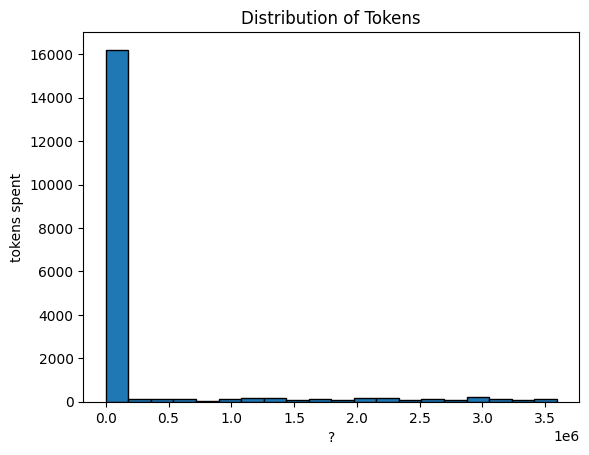

In [162]:
# doesnt really tell me much
tokens_sorted['total_tokens'].plot(kind='hist', bins=20, edgecolor='black')
plt.title('Distribution of Tokens')
plt.xlabel('?')
plt.ylabel('tokens spent')
plt.show()

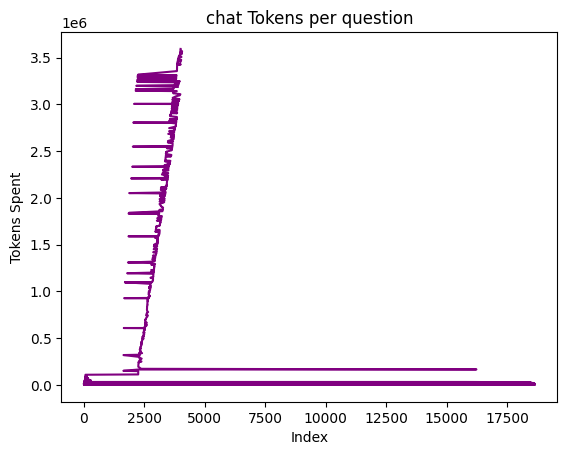

In [163]:
tokens_sorted['total_tokens'].plot(kind='line', color='purple')
plt.title('chat Tokens per question')
plt.xlabel('Index')
plt.ylabel('Tokens Spent')
plt.show()

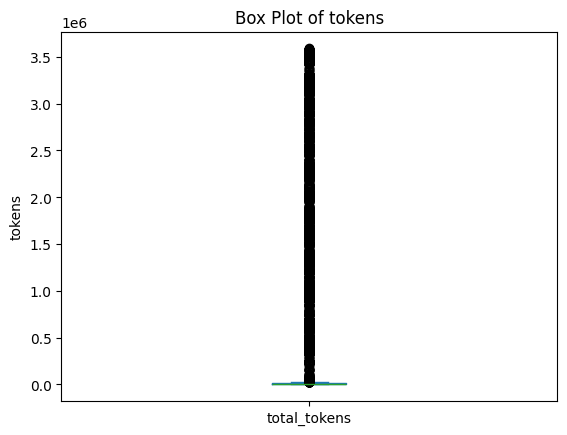

In [164]:
tokens_sorted['total_tokens'].plot(kind='box')
plt.title('Box Plot of tokens')
plt.ylabel('tokens')
plt.show()

In [165]:
# why are some tokens really high?

###Performance

In [166]:
performance.shape

(18631, 10)

In [167]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18631 entries, 0 to 18630
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                18631 non-null  datetime64[ns]
 1   chat_id                  18631 non-null  object        
 2   processing_time_seconds  18631 non-null  float64       
 3   total_tokens             18631 non-null  int64         
 4   input_tokens             18631 non-null  int64         
 5   output_tokens            18631 non-null  int64         
 6   model_calls              18631 non-null  int64         
 7   tool_calls_count         18631 non-null  int64         
 8   primary_category         18627 non-null  object        
 9   selected_agent           18631 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 1.4+ MB


In [168]:
performance.head()

,timestamp,chat_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,primary_category,selected_agent
0,2025-12-01 17:43:26.317,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,2.707687,6935,6884,51,5,0,greetings,reporter
1,2025-12-01 17:44:10.986,282ee6d2-7636-4f56-a008-b5aed0db3a99,6.914212,12007,11846,161,8,0,sunport_amenities,reporter
2,2025-12-01 17:56:49.748,561b0d0f-a468-437f-b18d-0f8f19b22ad6,5.940034,17029,16734,295,8,0,sunport_amenities,reporter
3,2025-12-01 18:05:36.912,6479cd1e-d8d9-4be4-9e40-63bc844d1c2c,3.768406,18477,18106,371,6,0,sunport_amenities,reporter
4,2025-12-01 18:05:50.201,5c01f807-5abd-49c9-b594-b80dc068b953,4.330594,20034,19539,495,6,0,greetings,reporter


In [169]:
performance.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
timestamp,18631,2026-02-12 20:36:19.075953152,2025-12-01 17:43:26.317000,2025-12-29 01:59:53.632999936,2025-12-29 03:21:35.638000128,2026-03-24 00:14:11.188499968,2026-07-30 04:11:12.907000,NaN
processing_time_seconds,18631.0,14.577398,0.0,2.936825,4.780313,11.605106,263.594091,27.740849
total_tokens,18631.0,252060.028823,457.0,1793.0,2569.0,10052.0,3591772.0,728484.855747
input_tokens,18631.0,244658.868016,441.0,1640.0,2360.0,9909.5,3487756.0,706896.205058
output_tokens,18631.0,7401.160807,11.0,87.0,120.0,235.0,113868.0,21658.240257
model_calls,18631.0,4.143524,0.0,3.0,4.0,5.0,36.0,2.724457
tool_calls_count,18631.0,0.687027,0.0,0.0,1.0,1.0,16.0,0.532873


In [170]:
performance.loc[
  performance['processing_time_seconds'] == 263.594091,
  ['chat_id', 'processing_time_seconds', 'model_calls', 'tool_calls_count', 'selected_agent']
]

,chat_id,processing_time_seconds,model_calls,tool_calls_count,selected_agent
6042,a869bc65-ad44-44a2-bb2b-bec23bb4f026,263.594091,5,0,reporter


####Rows

In [171]:
#Rows w/Nulls
performance.isnull().sum().sort_values()

,0
timestamp,0
chat_id,0
processing_time_seconds,0
total_tokens,0
input_tokens,0
output_tokens,0
model_calls,0
tool_calls_count,0
selected_agent,0
primary_category,4


In [172]:
performance[performance['primary_category'].isna()]

,timestamp,chat_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,primary_category,selected_agent
814,2025-12-25 22:19:02.830,2c597056-3765-4c83-9200-ccfc17fc8a5f,2.786840,11399,11276,123,5,0,NaN,reporter
816,2025-12-25 22:43:51.690,5f713fa5-3e4d-46df-a245-e88f701b54f4,6.447419,9941,9833,108,8,0,NaN,reporter
817,2025-12-25 22:44:14.960,182a80f4-57d2-4a42-9ff5-92f50e18fa53,2.728706,8854,8693,161,4,1,NaN,reporter
818,2025-12-25 22:58:43.874,009f00aa-d28a-44e3-83ee-20807aaac60f,5.234607,1790,1655,135,6,1,NaN,reporter


In [173]:
#Fill
performance.loc[814, 'primary_category']= 'sunport_amenities'
performance.loc[816, 'primary_category']= 'navigation'
performance.loc[817, 'primary_category']= 'navigation'
performance.loc[818, 'primary_category']= 'airline_logistics'

In [174]:
performance[performance['primary_category'].isna()]

,timestamp,chat_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,primary_category,selected_agent


In [175]:
#Missing Rows
performance[performance.isnull().any(axis=1)]

,timestamp,chat_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,primary_category,selected_agent


In [176]:
#Duplicate rows
performance.duplicated().sum()

np.int64(0)

###User Feedback

In [177]:
user_feedback.shape

(786, 7)

In [178]:
user_feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786 entries, 0 to 785
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           786 non-null    datetime64[ns]
 1   timestamp      786 non-null    datetime64[ns]
 2   ip_address     786 non-null    object        
 3   star_rating    781 non-null    float64       
 4   feedback_text  5 non-null      object        
 5   chat_id        786 non-null    object        
 6   session_id     786 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 43.1+ KB


In [179]:
user_feedback.head()

,date,timestamp,ip_address,star_rating,feedback_text,chat_id,session_id
0,2025-12-01,2025-12-01 22:23:07.619,100.100.0.4,5.0,NaN,fa9a7d7a-3358-4b87-97c7-925db0f9ea9a,31fe8ede-010a-4690-a51e-1902e195ad84
1,2025-12-01,2025-12-01 22:23:45.319,100.100.0.204,5.0,NaN,6edb7220-b5f9-45c1-b25a-752abd9ab45d,31fe8ede-010a-4690-a51e-1902e195ad84
2,2025-12-01,2025-12-01 22:25:59.759,100.100.0.4,5.0,NaN,6dc25bdb-6bf6-4494-ac86-305280bcf482,31fe8ede-010a-4690-a51e-1902e195ad84
3,2025-12-01,2025-12-01 22:26:30.895,100.100.0.204,5.0,NaN,0eeba6de-b99c-4d36-a932-2a004bdcb9eb,31fe8ede-010a-4690-a51e-1902e195ad84
4,2025-12-01,2025-12-01 22:28:23.858,100.100.0.103,5.0,NaN,ed612f00-6738-4d73-ace2-09fc47882ef0,31fe8ede-010a-4690-a51e-1902e195ad84


####Rows

In [180]:
#Rows w/Nulls
user_feedback.isnull().sum().sort_values()

,0
date,0
timestamp,0
ip_address,0
chat_id,0
session_id,0
star_rating,5
feedback_text,781


In [181]:
user_feedback[user_feedback['star_rating'].isna()]

,date,timestamp,ip_address,star_rating,feedback_text,chat_id,session_id
147,2025-12-24,2025-12-24 00:36:44.421,100.100.0.4,NaN,Took a bit of time but answer was great.,0f710491-a1fb-4742-ab14-ca72a3e0dd33,e3c60ae2-c602-413c-9004-9586700a8364
262,2025-12-30,2025-12-30 12:41:51.168,100.100.0.204,NaN,I thought we fixed this outdated data,c55198b4-1deb-46e2-aa97-79b82fefc519,36d74f4f-fab1-48d2-a614-b2e92dce4a79
309,2026-01-02,2026-01-02 11:26:57.492,100.100.0.203,NaN,You should have a live number of parking space...,afdba081-c8bc-4ce3-aec4-6fb4fbdb355a,a3d925e8-31d4-43ff-9eaa-68f50bba8685
311,2026-01-02,2026-01-02 15:47:12.870,100.100.0.4,NaN,formatting need work,578834f9-d399-4700-9ec7-3ba96640f969,4fce5ccc-683e-4d37-8b0e-c8c8e0e05bbe
761,2026-07-17,2026-07-17 04:02:23.735,100.100.0.4,NaN,Please find a way to be able to report real-ti...,ed78ddae-6a66-42e1-aee4-daa8d49a9f84,17b0800a-dd75-4cf1-82a7-42e45d7b5615


In [182]:
user_feedback[user_feedback['feedback_text'].notna()]

,date,timestamp,ip_address,star_rating,feedback_text,chat_id,session_id
147,2025-12-24,2025-12-24 00:36:44.421,100.100.0.4,NaN,Took a bit of time but answer was great.,0f710491-a1fb-4742-ab14-ca72a3e0dd33,e3c60ae2-c602-413c-9004-9586700a8364
262,2025-12-30,2025-12-30 12:41:51.168,100.100.0.204,NaN,I thought we fixed this outdated data,c55198b4-1deb-46e2-aa97-79b82fefc519,36d74f4f-fab1-48d2-a614-b2e92dce4a79
309,2026-01-02,2026-01-02 11:26:57.492,100.100.0.203,NaN,You should have a live number of parking space...,afdba081-c8bc-4ce3-aec4-6fb4fbdb355a,a3d925e8-31d4-43ff-9eaa-68f50bba8685
311,2026-01-02,2026-01-02 15:47:12.870,100.100.0.4,NaN,formatting need work,578834f9-d399-4700-9ec7-3ba96640f969,4fce5ccc-683e-4d37-8b0e-c8c8e0e05bbe
761,2026-07-17,2026-07-17 04:02:23.735,100.100.0.4,NaN,Please find a way to be able to report real-ti...,ed78ddae-6a66-42e1-aee4-daa8d49a9f84,17b0800a-dd75-4cf1-82a7-42e45d7b5615


In [183]:
#Missing Rows
# user_feedback[user_feedback.isnull().any(axis=1)]

In [184]:
#Duplicate rows
user_feedback.duplicated().sum()

np.int64(0)

In [185]:
user_feedback.loc[
  user_feedback['session_id'].str.contains('fced9282-3523-461a-8a53-391fa279ce76', case=False, na=False),
  ['star_rating', 'session_id']
]

,star_rating,session_id
770,5.0,fced9282-3523-461a-8a53-391fa279ce76


###Daily Summary

In [186]:
daily_summary.shape

(234, 13)

In [187]:
daily_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          234 non-null    datetime64[ns]
 1   total_chats                   234 non-null    int64         
 2   processing_time_seconds_mean  234 non-null    float64       
 3   processing_time_seconds_min   234 non-null    float64       
 4   processing_time_seconds_max   234 non-null    float64       
 5   processing_time_seconds_sum   234 non-null    float64       
 6   total_tokens_mean             234 non-null    float64       
 7   total_tokens_sum              234 non-null    int64         
 8   input_tokens_sum              234 non-null    int64         
 9   output_tokens_sum             234 non-null    int64         
 10  model_calls_sum               234 non-null    int64         
 11  tool_calls_count_mean         23

In [205]:
daily_summary.head(40)

,date,total_chats,processing_time_seconds_mean,processing_time_seconds_min,processing_time_seconds_max,processing_time_seconds_sum,total_tokens_mean,total_tokens_sum,input_tokens_sum,output_tokens_sum,model_calls_sum,tool_calls_count_mean,tool_calls_count_sum
0,2025-12-01,23,5.18,2.71,17.00,119.21,11962.65,275141,258735,16406,124,0.00,0
1,2025-12-02,65,7.31,3.00,17.25,475.15,30317.97,1970668,1708700,261968,349,0.03,2
2,2025-12-03,49,5.68,2.46,19.01,278.18,26136.49,1280688,1193211,87477,288,0.00,0
3,2025-12-04,56,5.48,2.47,14.09,306.95,22017.55,1232983,1153771,79212,321,0.00,0
4,2025-12-05,37,6.23,2.98,13.27,230.59,18164.89,672101,609376,62725,179,0.00,0
5,2025-12-06,19,4.47,2.84,6.32,84.96,19671.68,373762,355748,18014,103,0.95,18
6,2025-12-08,72,5.72,2.52,17.18,411.86,14892.11,1072232,1000801,71431,417,0.65,47
7,2025-12-09,111,7.18,3.29,31.78,797.03,3921.24,435258,386746,48512,650,0.97,108
8,2025-12-10,1,6.21,6.21,6.21,6.21,1896.00,1896,1740,156,6,1.00,1
9,2025-12-11,78,6.27,2.81,14.16,489.18,3240.19,252735,235586,17149,466,0.97,76


In [189]:
daily_summary.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
date,234,2026-04-04 01:32:18.461538560,2025-12-01 00:00:00,2026-02-05 06:00:00,2026-04-04 12:00:00,2026-06-01 18:00:00,2026-07-30 00:00:00,NaN
total_chats,234.0,79.619658,1.0,27.0,35.5,46.75,8367.0,545.654512
processing_time_seconds_mean,234.0,5.089872,1.89,3.2875,3.99,4.99,30.44,4.065369
processing_time_seconds_min,234.0,0.973803,0.0,0.0,0.0,1.85,6.21,1.080553
processing_time_seconds_max,234.0,20.980983,2.51,9.615,13.1,21.3275,263.59,25.982222
processing_time_seconds_sum,234.0,1160.647692,3.49,99.825,152.35,242.1,223961.88,14628.970696
total_tokens_mean,234.0,8626.983162,1896.0,5137.02,5884.9,6572.7825,553728.51,35910.667382
total_tokens_sum,234.0,20068933.320513,1896.0,156908.75,210611.5,282059.5,4633046482.0,302854121.272936
input_tokens_sum,234.0,19479655.42735,1740.0,150680.25,204347.0,272143.5,4497555000.0,293997429.106369
output_tokens_sum,234.0,589277.893162,42.0,4315.0,6452.0,9572.75,135491482.0,8856705.91112


####Rows

In [190]:
#Rows w/Nulls
daily_summary.isnull().sum().sort_values()

,0
date,0
total_chats,0
processing_time_seconds_mean,0
processing_time_seconds_min,0
processing_time_seconds_max,0
processing_time_seconds_sum,0
total_tokens_mean,0
total_tokens_sum,0
input_tokens_sum,0
output_tokens_sum,0


In [191]:
#Missing Rows
daily_summary[daily_summary.isnull().any(axis=1)]

,date,total_chats,processing_time_seconds_mean,processing_time_seconds_min,processing_time_seconds_max,processing_time_seconds_sum,total_tokens_mean,total_tokens_sum,input_tokens_sum,output_tokens_sum,model_calls_sum,tool_calls_count_mean,tool_calls_count_sum


In [192]:
#Duplicate rows
daily_summary.duplicated().sum()

np.int64(0)

###Category Distribution

In [193]:
category_distribution.shape

(5, 4)

In [194]:
category_distribution.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   primary_category     5 non-null      object 
 1   count                5 non-null      int64  
 2   avg_processing_time  5 non-null      float64
 3   avg_tokens           5 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 292.0+ bytes


In [195]:
category_distribution.head()

,primary_category,count,avg_processing_time,avg_tokens
0,airline_logistics,5421,11.80,60572.36
1,general_info,803,14.98,399494.37
2,greetings,778,4.68,10995.79
3,navigation,2473,24.73,799836.39
4,sunport_amenities,9152,14.29,225130.19


####Rows

In [196]:
#Rows w/Nulls
category_distribution.isnull().sum().sort_values()

,0
primary_category,0
count,0
avg_processing_time,0
avg_tokens,0


In [197]:
#Missing Rows
category_distribution[category_distribution.isnull().any(axis=1)]

,primary_category,count,avg_processing_time,avg_tokens


In [198]:
#Duplicate rows
category_distribution.duplicated().sum()

np.int64(0)

###Hourly Pattern

In [199]:
hourly_pattern.shape

(24, 2)

In [200]:
hourly_pattern.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   hour    24 non-null     int64
 1   count   24 non-null     int64
dtypes: int64(2)
memory usage: 516.0 bytes


In [201]:
# it seems like the most amount of data is night time from 12pm - 3am
hourly_pattern

,hour,count
0,0,1364
1,1,2906
2,2,4245
3,3,1618
4,4,341
5,5,221
6,6,117
7,7,93
8,8,85
9,9,79


####Rows

In [202]:
#Rows w/Nulls
hourly_pattern.isnull().sum().sort_values()

,0
hour,0
count,0


In [203]:
#Missing Rows
hourly_pattern[hourly_pattern.isnull().any(axis=1)]

,hour,count


In [204]:
#Duplicate rows
hourly_pattern.duplicated().sum()

np.int64(0)

##Merge DataFrames

###Raw Data & Performance

In [ ]:
#raw_data_performance_merged = pd.merge(
#  raw_data,
#  performance,
#  on='chat_id'
#)

In [62]:
#raw_data_performance_merged.head()

In [63]:
#raw_data_performance_merged.shape

In [64]:
#duplicates = raw_data_performance_merged.columns.intersection(user_feedback.columns)
#duplicates

In [65]:
#user_feedback.head()

In [66]:
#merged_df = raw_data_performance_merged.merge(
#    user_feedback[["chat_id", "star_rating", "feedback_text"]],
#    on="chat_id",
#    how="left"
#)

In [67]:
#merged_df.head()

In [68]:
#merged_df.info()

In [69]:
#merged_df.columns.tolist()

#Token exploration
looking at raw data

In [70]:
# I would like to see the ones with the most tokens and the ones with less tokens total


In [71]:
# asending the data from greatest to smallest it seems like
tokens_sorted = merged_df.sort_values(by='total_tokens_y', ascending=True)

pd.set_option('display.max_columns', None)
tokens_sorted

NameError: name 'merged_df' is not defined